In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\ai4i2020.csv")
print(df.head(-10))

       UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0        1     M14860    M                298.1                    308.6   
1        2     L47181    L                298.2                    308.7   
2        3     L47182    L                298.1                    308.5   
3        4     L47183    L                298.2                    308.6   
4        5     L47184    L                298.2                    308.7   
...    ...        ...  ...                  ...                      ...   
9985  9986     H39399    H                298.7                    308.5   
9986  9987     M24846    M                298.8                    308.6   
9987  9988     M24847    M                298.8                    308.6   
9988  9989     L57168    L                298.9                    308.6   
9989  9990     M24849    M                298.8                    308.5   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  \
0       

In [8]:
print("Data Shape is - ",df.shape)
print("Count of Machines by",df.value_counts("Type"))

Data Shape is -  (10000, 14)
Count of Machines by Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [9]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [10]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [11]:
X = df.drop(columns=['UDI', 'Product ID', 'Type', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df['Machine failure']

In [12]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
model = RandomForestClassifier()
model.fit(X_train_scaled, y_train)

RandomForestClassifier()

In [16]:
y_pred = model.predict(x_test)

c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1939
           1       0.03      1.00      0.06        61

    accuracy                           0.03      2000
   macro avg       0.02      0.50      0.03      2000
weighted avg       0.00      0.03      0.00      2000



c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
model2.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [19]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[   0 1939]
 [   0   61]]


In [20]:
y_proba = model2.predict_proba(x_test)[:, 1]

# turunin threshold
y_pred = (y_proba > 0.3).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.69      0.67      0.68        61

    accuracy                           0.98      2000
   macro avg       0.84      0.83      0.84      2000
weighted avg       0.98      0.98      0.98      2000



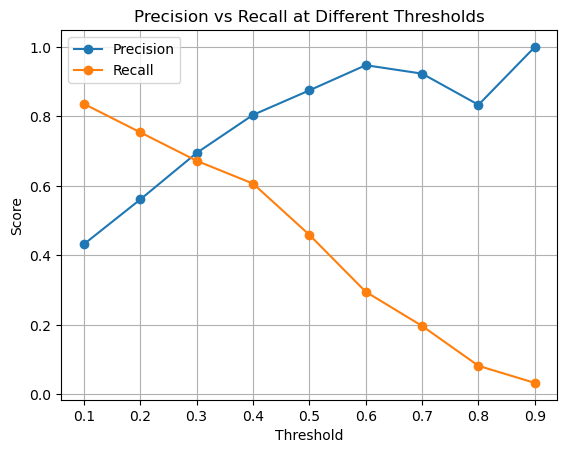

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

y_proba = model2.predict_proba(x_test)[:, 1]

thresholds = np.linspace(0.1, 0.9, 9)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_proba > t).astype(int)
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))

# Plot
plt.figure()
plt.plot(thresholds, precisions, marker='o', label="Precision")
plt.plot(thresholds, recalls, marker='o', label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")
plt.legend()
plt.grid()
plt.show()

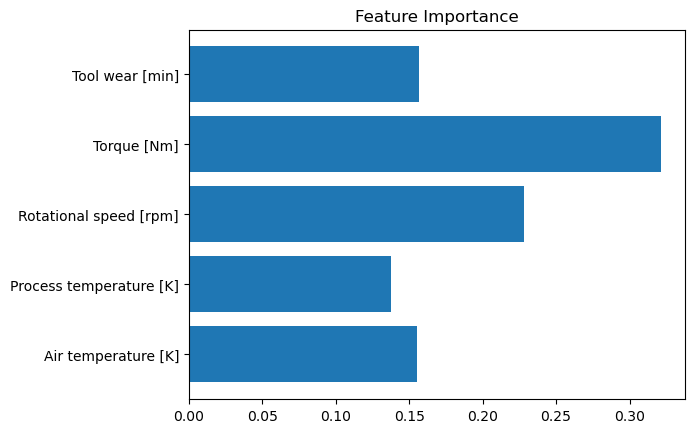

In [22]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

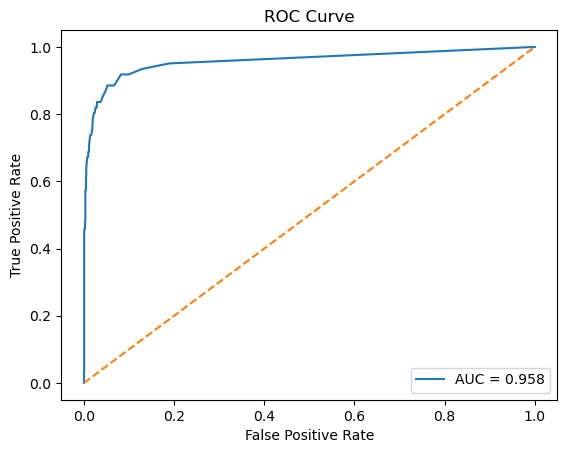

In [23]:
# ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ambil probabilitas kelas 1 (failure)
y_probs = model2.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

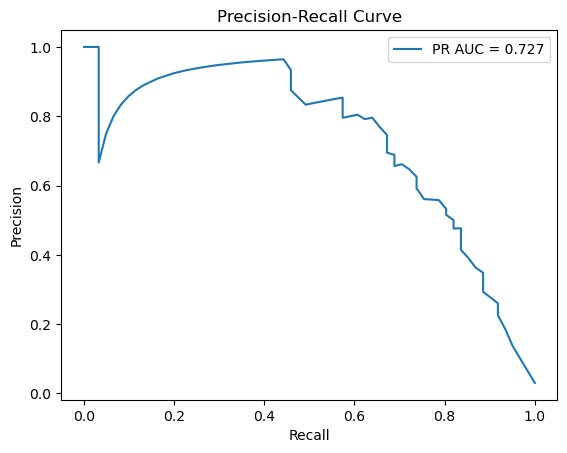

In [24]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [25]:
# Drop columns that aren't physical features
df_cleaned = df.drop(['UDI', 'Product ID', 'Type'], axis=1)

In [26]:
# Use these values to set st.slider(min, max) in Streamlit
input_bounds = df_cleaned.describe().loc[['min', 'max']]
print(input_bounds)

     Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
min                295.3                    305.7                  1168.0   
max                304.5                    313.8                  2886.0   

     Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
min          3.8              0.0              0.0  0.0  0.0  0.0  0.0  0.0  
max         76.6            253.0              1.0  1.0  1.0  1.0  1.0  1.0  


In [28]:
import joblib

# Save the trained model
joblib.dump(model, 'machine_failure_model.pkl')

# Save the scaler (Crucial: Use the one fitted on X_train only)
joblib.dump(scaler, 'app_scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [29]:
def predict_failure(air_temp, process_temp, speed, torque, wear):
    # 1. Load artifacts
    loaded_model = joblib.load('machine_failure_model.pkl')
    loaded_scaler = joblib.load('app_scaler.pkl')
    
    # 2. Convert input to dataframe/array
    features = np.array([[air_temp, process_temp, speed, torque, wear]])
    
    # 3. Scale the input
    scaled_features = loaded_scaler.transform(features)
    
    # 4. Predict
    prediction = loaded_model.predict(scaled_features)
    return "Failure Predicted" if prediction[0] == 1 else "No Failure"

# Test the function
print(predict_failure(300, 310, 1500, 40, 50))

No Failure


c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
